In [1]:
%load_ext autoreload
%autoreload 2

import os
import wandb
import torch
import random
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import sys

# Add parent directory to path to access modules
sys.path.append('..')

from torch.utils.data import Dataset

from modules.dna_tokenizer import DNATokenizer
from modules.bert_config import BertConfig
from modules.custom_bert import DNABertForMaskedLM
from helpers.conf_matrix import plot_evaluation_results

from transformers import DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback

/home/shishir-sunar/anaconda3/envs/insdel_glm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Global configuration wandb
os.environ["WANDB_PROJECT"] = "dna-indel-prediction"  # project name
os.environ["WANDB_LOG_MODEL"] = "false"
# os.environ["WANDB_API_KEY"] = api key should be set in terminal

# Initialer Login (falls noch nicht geschehen)
wandb.login()

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Using device: ", device)

wandb: Currently logged in as: shishir-sunar9 (shishir-sunar9-technical-university-of-munich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Using device:  cuda


In [3]:
# Create tokenizer
tokenizer = DNATokenizer(vocab=None, deletion_token=True)

# Test
seq = "ATCGATCG"
tokens = tokenizer(seq, return_tensors="pt")
print(tokens)

{'input_ids': tensor([[7, 0, 1, 2, 3, 0, 1, 2, 3, 8, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5,

In [4]:
with open("../config.json", "r") as f:
    config_dict = json.load(f)

# Synchronize config with tokenizer
config_dict["vocab_size"] = tokenizer.vocab_size
config_dict["pad_token_id"] = tokenizer.pad_token_id
config_dict["mask_token_id"] = tokenizer.mask_token_id
config_dict["sep_token_id"] = tokenizer.sep_token_id
config_dict["cls_token_id"] = tokenizer.cls_token_id

config = BertConfig(**config_dict)
model = DNABertForMaskedLM(config)

print(f"Model initialized with:")
print(f" - Vocab size: {config.vocab_size}")
print(f" - Pad token ID: {config.pad_token_id} (Token: {tokenizer.ids_to_tokens[config.pad_token_id]})")
print(f" - Mask token ID: {config.mask_token_id} (Token: {tokenizer.ids_to_tokens[config.mask_token_id]})")
print(f" - CLS token ID: {config.cls_token_id} (Token: {tokenizer.ids_to_tokens[config.cls_token_id]})")

Model initialized with:
 - Vocab size: 9
 - Pad token ID: 5 (Token: [PAD])
 - Mask token ID: 6 (Token: [MASK])
 - CLS token ID: 7 (Token: [CLS])


In [5]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15  # fraction of nucleotides to mask
)

In [6]:
class DNADataset(Dataset):
    def __init__(self, sequences, tokenizer, max_length=32): # Changed from 40 to 42 to accommodate [CLS] and [SEP]
        self.sequences = sequences
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        item = self.tokenizer(
                    self.sequences[idx],
                    padding="max_length",
                    max_length=self.max_length,
                    truncation=True
                )
        return {k: v.squeeze(0) for k, v in item.items()}


train_df = pd.read_parquet("../data/simulated/train.parquet")
val_df   = pd.read_parquet("../data/simulated/val.parquet")

train_sequences = train_df["sequences"].tolist()
val_sequences   = val_df["sequences"].tolist()

train_dataset = DNADataset(sequences=train_sequences, tokenizer=tokenizer, max_length=train_df["sequences"].str.len().max()+2)
eval_dataset  = DNADataset(sequences=val_sequences, tokenizer=tokenizer, max_length=val_df["sequences"].str.len().max()+2)

print(f"Loaded {len(train_dataset)} training samples and {len(eval_dataset)} validation samples.")

Loaded 60000 training samples and 20000 validation samples.


In [7]:
sample = train_dataset[0]
print(sample["input_ids"].shape)

torch.Size([142])


In [8]:
# Mode Collapse Mitigation Strategy:
# 1. Lower Learning Rate: 1e-4 -> 2e-5
# 2. Add Warmup: 10% of total steps
# 3. Add Weight Decay: 0.01 for regularization
# 4. Label Smoothing: 0.1 (added support in custom_bert.py)
# 5. Gradient Clipping: 1.0

# Calculate warmup steps (10% of total steps)

num_train_epochs = 50
batch_size = 32
total_steps = (len(train_dataset) // batch_size) * num_train_epochs
warmup_steps = int(0.1 * total_steps)

# Update config with label smoothing
config.label_smoothing = 0.0

training_args = TrainingArguments(
    output_dir="../checkpoints/simulated_model_deletion_140_v2",
    num_train_epochs=num_train_epochs,  
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,  
    learning_rate=1e-5,          # Lower learning rate
    weight_decay=0.01,           # Add weight decay
    warmup_steps=warmup_steps,   # Add warmup
    max_grad_norm=1.5,           # Gradient clipping
    report_to="wandb",
    run_name="simulated_data_deletion_140_v2"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.001)]
)

# Start fresh training
trainer.train(resume_from_checkpoint=False)

wandb.finish()

Epoch,Training Loss,Validation Loss
1,2.176300,2.174129
2,2.087500,2.081226
3,1.963000,1.957013
4,1.845800,1.841655
5,1.746900,1.742612
6,1.673800,1.673311
7,1.632800,1.629266
8,1.602500,1.597792
9,1.582200,1.574243
10,1.562300,1.556847


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


eval/loss,█▇▆▅▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/runtime,▁▁▁▂▁▁█▁▁▁▁▁▁▂▁▁▁▂▁▁▂▂▂▁
eval/samples_per_second,███▇██▁█▇████▆█▇█▇█▇▇▇▇█
eval/steps_per_second,███▇██▁█▇████▆█▇█▇█▇▇▇▇█
train/epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇████
train/global_step,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆█████
train/grad_norm,█████▇▆▆▅▅▃▃▂▁▂▁▁▂▂▁▁▃▂▁▃▂▂▂▂▁▂▂▂▂▂▂▂▂▂▂
train/learning_rate,▁▁▂▂▂▃▄▅█████████▇▇▇▇▆▆▆▆▆▆▆▆▆▆▅▅▅▅▅▅▅▅▅
train/loss,█▆▅▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/loss,1.50726
eval/runtime,4.2758


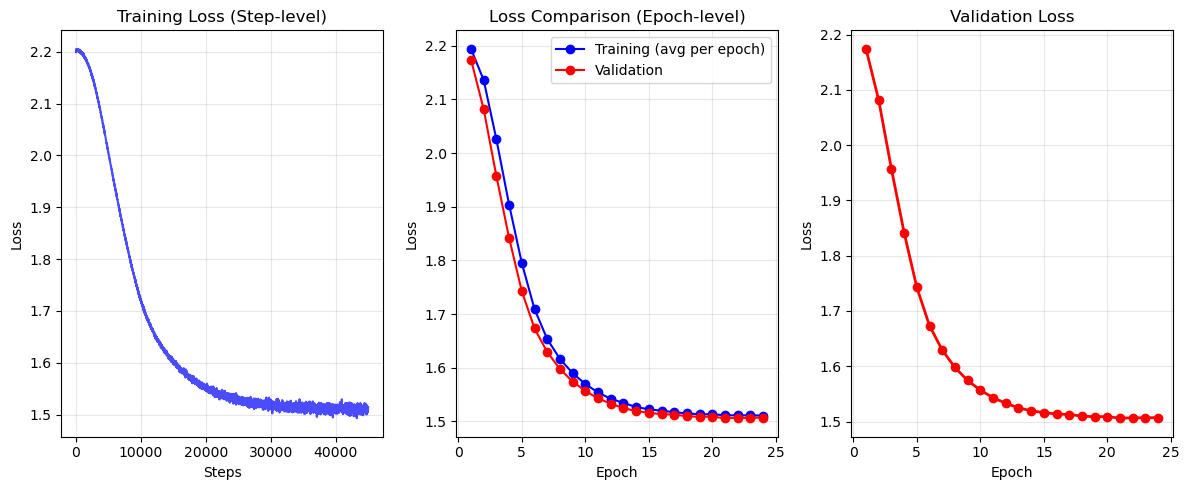

In [9]:
# Plot loss curves
logs = trainer.state.log_history
train_logs = [x for x in logs if 'loss' in x and 'eval_loss' not in x]
eval_logs = [x for x in logs if 'eval_loss' in x]

# Get step-level training loss
train_steps = [x['step'] for x in train_logs]
train_losses = [x['loss'] for x in train_logs]

# Get epoch-level validation loss
eval_epochs = [x['epoch'] for x in eval_logs]
eval_losses = [x['eval_loss'] for x in eval_logs]

# Calculate epoch-averaged training loss
# Note: Validation loss is often lower than training loss because:
# 1. Dropout is active during training, adding noise and increasing loss.
# 2. Training loss is averaged over the epoch, while validation loss is measured at the end (when the model is better).
epochs = list(range(1, int(max(eval_epochs)) + 1))
train_loss_per_epoch = []

batch_size = training_args.per_device_train_batch_size
steps_per_epoch = len(train_dataset) // (batch_size * training_args.gradient_accumulation_steps if hasattr(training_args, 'gradient_accumulation_steps') else batch_size)

for epoch in epochs:
    epoch_start = (epoch - 1) * steps_per_epoch
    epoch_end = epoch * steps_per_epoch
    
    epoch_losses = [loss for step, loss in zip(train_steps, train_losses) 
                    if epoch_start < step <= epoch_end]
    
    if epoch_losses:
        train_loss_per_epoch.append(np.mean(epoch_losses))
    else:
        train_loss_per_epoch.append(None)

plt.figure(figsize=(12, 5))

# Plot 1: Step-level training loss
plt.subplot(1, 3, 1)
plt.plot(train_steps, train_losses, 'b-', alpha=0.7)
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss (Step-level)')
plt.grid(True, alpha=0.3)

# Plot 2: Epoch-level comparison
plt.subplot(1, 3, 2)
plt.plot(epochs, train_loss_per_epoch, 'bo-', label='Training (avg per epoch)')
plt.plot(eval_epochs, eval_losses, 'ro-', label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Comparison (Epoch-level)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Validation loss only
plt.subplot(1, 3, 3)
plt.plot(eval_epochs, eval_losses, 'ro-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
project_root = Path.cwd().parent
save_directory = project_root / "model" / "Mamba_deletion_100k_1e-5"

trainer.save_model(str(save_directory))

Running prediction on Validation set...


Total DNA tokens for evaluation: 90279


/home/shishir-sunar/InsDelGLM/notebooks/../helpers/conf_matrix.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts_ordered, palette="viridis")


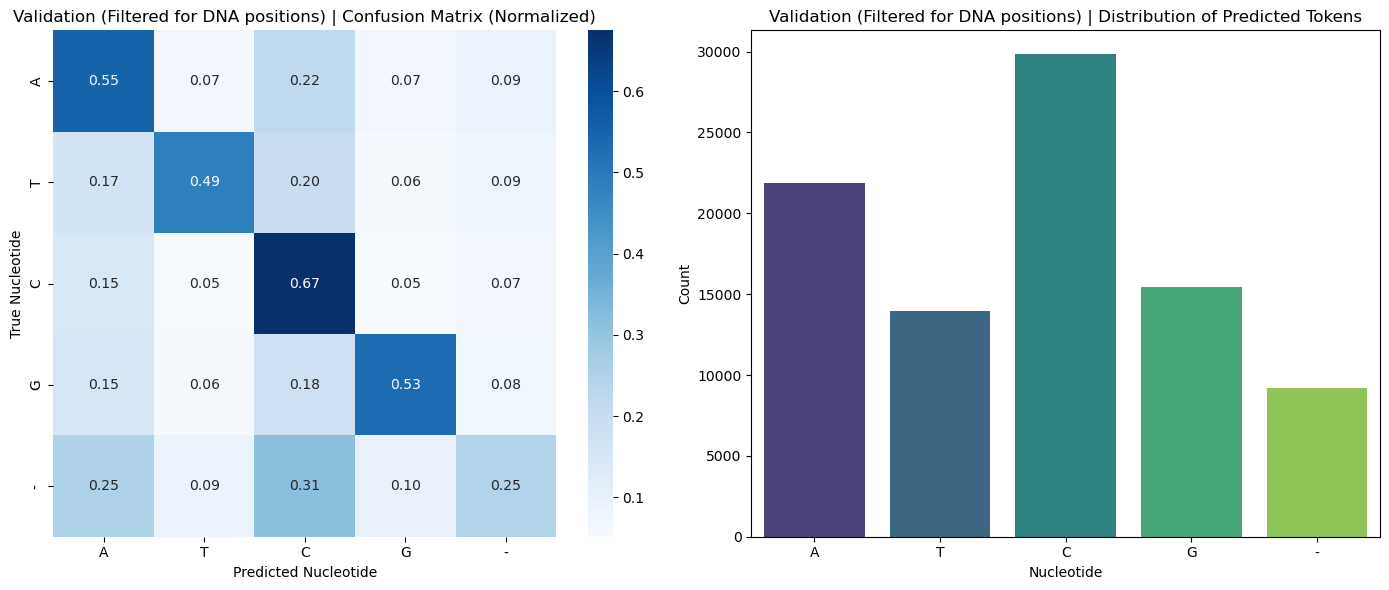

In [11]:
# Load the saved model
project_root = Path.cwd().parent
model_directory = project_root / "model" / "Tiger_deletion_100k_1e-5"

from safetensors.torch import load_file

# Update config before loading to ensure alignment
with open("../config_baseline.json", "r") as f:
    config_dict = json.load(f)
config_dict["vocab_size"] = tokenizer.vocab_size
config_dict["pad_token_id"] = tokenizer.pad_token_id
config_dict["mask_token_id"] = tokenizer.mask_token_id
config_dict["sep_token_id"] = tokenizer.sep_token_id
config_dict["cls_token_id"] = tokenizer.cls_token_id
config = BertConfig(**config_dict)

loaded_model = DNABertForMaskedLM(config)
state_dict = load_file(model_directory / "model.safetensors")
loaded_model.load_state_dict(state_dict)
loaded_model.to(device)
loaded_model.eval()

# Create evaluation arguments
eval_args = TrainingArguments(
    output_dir="../checkpoints/temp_eval",
    per_device_eval_batch_size=16,
    do_train=False,
    do_eval=True,
)

eval_trainer = Trainer(
    model=loaded_model,
    args=eval_args,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
)

print("Running prediction on Validation set...")
output = eval_trainer.predict(eval_dataset)

logits = output.predictions
labels = output.label_ids
pred_ids_flat = np.argmax(logits, axis=-1).flatten()
labels_flat = labels.flatten()

# EVALUATION FILTERING LOGIC:
# 1. Labels != -100: Only look at masked positions
# 2. Labels not in special_ids: Only look at positions that were originally DNA bases
special_ids = tokenizer.all_special_ids
mask = (labels_flat != -100)
for sid in special_ids:
    mask &= (labels_flat != sid)

true_ids_filtered = labels_flat[mask]
pred_ids_filtered = pred_ids_flat[mask]

# If the model predicts a special token (like [CLS]) for a DNA base, 
# it will still show up as a column in the confusion matrix unless we map it to an "Other" category.
# However, it is informative to see exactly what the model is hallucinating.

print(f"Total DNA tokens for evaluation: {len(true_ids_filtered)}")

plot_evaluation_results(
    true_ids_filtered,
    pred_ids_filtered,
    tokenizer,
    dataset_name="Validation (Filtered for DNA positions)"
)

In [13]:
# Additional analysis for prediction bias
from collections import Counter

def analyze_bias(true_ids, pred_ids, tokenizer):
    true_counts = Counter(true_ids)
    pred_counts = Counter(pred_ids)
    
    print("\nPrediction Distribution Analysis:")
    print(f"{'Token':<10} | {'True Count':<12} | {'Pred Count':<12} | {'Recall':<8}")
    print("-" * 50)
    
    for token_id in sorted(true_counts.keys()):
        token_name = tokenizer.ids_to_tokens[token_id]
        t_count = true_counts[token_id]
        p_count = pred_counts.get(token_id, 0)
        
        # Calculate how many of the true instances were predicted correctly
        correct = np.sum((true_ids == token_id) & (pred_ids == token_id))
        recall = correct / t_count if t_count > 0 else 0
        
        print(f"{token_name:<10} | {t_count:<12} | {p_count:<12} | {recall:.2%}")

analyze_bias(true_ids_filtered, pred_ids_filtered, tokenizer)


Prediction Distribution Analysis:
Token      | True Count   | Pred Count   | Recall  
--------------------------------------------------
A          | 20098        | 14149        | 42.11%
T          | 21812        | 25598        | 57.64%
C          | 25084        | 28562        | 62.41%
G          | 23285        | 21970        | 55.53%
